# Asset Management: TEMPLATE FOR STRATEGY DEVELOPMENT


### (Not submission, just for standarization and make it easier to combine)







.

## Strategy: FILL YOUR STRATEGY
## Student:  STUDENT NUMBER







.

## 1. Data preparation

In [31]:
import pandas as pd

base = "C:/Users/yinsiyuan/Desktop/2nd/Asset Mgmt/Assign/data/"

annual_data  = pd.read_csv(base + "DE_AT_CH_data_annual.csv")
monthly_data = pd.read_csv(base + "DE_AT_CH_data_monthly.csv")
firms        = pd.read_csv(base + "DE_AT_CH_firms.csv")
factors      = pd.read_csv(base + "Europe_FF_Factors.csv")

print(annual_data.head())
print(monthly_data.head())
print(factors.head())

print(monthly_data.info())  
print(firms.info())

           ISIN  fyear    BEME      OP     INV
0  AT000000STR1   2007  0.5038  0.2386  0.3947
1  AT000000STR1   2008  1.5017  0.2867  0.2589
2  AT000000STR1   2009  1.2163  0.3091 -0.0153
3  AT000000STR1   2010  1.2520  0.2903  0.0726
4  AT000000STR1   2011  1.1162  0.3335  0.0044
           ISIN   mdate     RET   RET11        ME       b       h       s    ivol
0  DE000A11QW68  200606 -0.0264  0.3490  100.6032  1.7711  1.9829  2.2792  0.0243
1  DE000A11QW68  200607 -0.1719 -0.0728   83.3189  1.9704  1.3950  2.1592  0.0147
2  DE000A11QW68  200608 -0.0005 -0.2091   83.2671  2.0917  0.5516  2.4282  0.0298
3  DE000A11QW68  200609 -0.1441 -0.1636   71.2674  2.1569  1.4690  2.0897  0.0166
4  DE000A11QW68  200610 -0.4920 -0.5568   36.1973  1.7767  2.1637  2.2076  0.0674
    mdate   MktRF     SMB     HML      RF     WML
0  199106 -0.0741  0.0061 -0.0069  0.0042  0.0054
1  199107  0.0530 -0.0323 -0.0035  0.0049  0.0506
2  199108  0.0142 -0.0093 -0.0008  0.0046  0.0377
3  199109  0.0302  0.0173 

## Import and loading  (Remember to copy as path from your location file)

In [32]:
import pandas as pd
import numpy as np

# Set display options (nice for debugging)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Base path
base = r"C:/Users/yinsiyuan/Desktop/2nd/Asset Mgmt/Assign/data/"

# Load data
annual_data  = pd.read_csv(base + "DE_AT_CH_data_annual.csv")
monthly_data = pd.read_csv(base + "DE_AT_CH_data_monthly.csv")
firms        = pd.read_csv(base + "DE_AT_CH_firms.csv")
factors      = pd.read_csv(base + "Europe_FF_Factors.csv")

# Quick inspection
print("ANNUAL")
print(annual_data.head(), "\n")

print("MONTHLY")
print(monthly_data.head(), "\n")

print("FACTORS")
print(factors.head(), "\n")

print("MONTHLY INFO")
print(monthly_data.info())

print("FIRMS INFO")
print(firms.info())

ANNUAL
           ISIN  fyear    BEME      OP     INV
0  AT000000STR1   2007  0.5038  0.2386  0.3947
1  AT000000STR1   2008  1.5017  0.2867  0.2589
2  AT000000STR1   2009  1.2163  0.3091 -0.0153
3  AT000000STR1   2010  1.2520  0.2903  0.0726
4  AT000000STR1   2011  1.1162  0.3335  0.0044 

MONTHLY
           ISIN   mdate     RET   RET11        ME       b       h       s    ivol
0  DE000A11QW68  200606 -0.0264  0.3490  100.6032  1.7711  1.9829  2.2792  0.0243
1  DE000A11QW68  200607 -0.1719 -0.0728   83.3189  1.9704  1.3950  2.1592  0.0147
2  DE000A11QW68  200608 -0.0005 -0.2091   83.2671  2.0917  0.5516  2.4282  0.0298
3  DE000A11QW68  200609 -0.1441 -0.1636   71.2674  2.1569  1.4690  2.0897  0.0166
4  DE000A11QW68  200610 -0.4920 -0.5568   36.1973  1.7767  2.1637  2.2076  0.0674 

FACTORS
    mdate   MktRF     SMB     HML      RF     WML
0  199106 -0.0741  0.0061 -0.0069  0.0042  0.0054
1  199107  0.0530 -0.0323 -0.0035  0.0049  0.0506
2  199108  0.0142 -0.0093 -0.0008  0.0046  0.0377

## Panel Structure

In [33]:
# Check duplicates in annual data
annual_dupes = annual_data.duplicated(subset=["ISIN", "fyear"]).sum()
print("Annual duplicates:", annual_dupes)

# Check duplicates in monthly data
monthly_dupes = monthly_data.duplicated(subset=["ISIN", "mdate"]).sum()
print("Monthly duplicates:", monthly_dupes)

# Number of firms
print("Unique firms (annual):", annual_data["ISIN"].nunique())
print("Unique firms (monthly):", monthly_data["ISIN"].nunique())

# Time coverage
print("Monthly date range:", monthly_data["mdate"].min(), "to", monthly_data["mdate"].max())
print("Annual year range:", annual_data["fyear"].min(), "to", annual_data["fyear"].max())


Annual duplicates: 0
Monthly duplicates: 0
Unique firms (annual): 1546
Unique firms (monthly): 1546
Monthly date range: 199106 to 202006
Annual year range: 1990 to 2019


## Fix dates (YYYYMM → month-end datetime) &  Notebook Block 4 — Merge factors into the monthly panel

In [34]:
import pandas as pd

# Convert YYYYMM integers like 200606 -> Timestamp('2006-06-30')
monthly_data["date"] = pd.to_datetime(monthly_data["mdate"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
factors["date"]      = pd.to_datetime(factors["mdate"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

# Sort for clean panel operations later
monthly_data = monthly_data.sort_values(["ISIN", "date"]).reset_index(drop=True)
factors      = factors.sort_values(["date"]).reset_index(drop=True)

# Quick sanity check
print(monthly_data[["ISIN", "mdate", "date"]].head())
print(factors[["mdate", "date"]].head())
print("Monthly date range:", monthly_data["date"].min(), "to", monthly_data["date"].max())
print("Factors date range:", factors["date"].min(), "to", factors["date"].max())

monthly = monthly_data.merge(
    factors[["date", "MktRF", "SMB", "HML", "RF", "WML"]],
    on="date",
    how="left",
    validate="m:1"   # many firms per month -> one factor row per month
)

# Merge diagnostics
missing = monthly[["MktRF","SMB","HML","RF","WML"]].isna().any(axis=1).mean()
print(f"Share of firm-month rows missing any factor: {missing:.4%}")

# Show a few rows
print(monthly.head())
print(monthly.info())

bad_months = monthly.loc[monthly["RF"].isna(), "date"].drop_duplicates().sort_values()
print("Unmatched months (sample):")
print(bad_months.head(20))
print("Count unmatched months:", bad_months.shape[0])


           ISIN   mdate       date
0  AT000000STR1  200808 2008-08-31
1  AT000000STR1  200809 2008-09-30
2  AT000000STR1  200810 2008-10-31
3  AT000000STR1  200811 2008-11-30
4  AT000000STR1  200812 2008-12-31
    mdate       date
0  199106 1991-06-30
1  199107 1991-07-31
2  199108 1991-08-31
3  199109 1991-09-30
4  199110 1991-10-31
Monthly date range: 1991-06-30 00:00:00 to 2020-06-30 00:00:00
Factors date range: 1991-06-30 00:00:00 to 2020-06-30 00:00:00
Share of firm-month rows missing any factor: 0.0000%
           ISIN   mdate     RET   RET11         ME       b       h       s    ivol       date   MktRF     SMB     HML  \
0  AT000000STR1  200808 -0.0787 -0.1853  7079.2492  1.3861  0.2508  0.6964  0.0208 2008-08-31 -0.0457  0.0011 -0.0009   
1  AT000000STR1  200809 -0.2988 -0.4384  4963.8915  1.5177  0.1330  0.7892  0.0283 2008-09-30 -0.1507 -0.0310  0.0091   
2  AT000000STR1  200810 -0.5557 -0.7252  2205.9514  1.5870  0.0412  1.5201  0.0519 2008-10-31 -0.2202 -0.0491 -0.0353   
3

# 2. Strategy Definition

## Parameters: 
(personalize as needed, reference to the variable names as before)

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [36]:
# =========================
# Strategy specification
# =========================

# Universe
UNIVERSE_DESC = "German/Austrian/Swiss equities with momentum and stop-loss overlay"
START_YYYYMM  = 199106
END_YYYYMM    = 202006

# Rebalance
REBALANCE_FREQ = "M"   # Monthly rebalancing

# Signal
SIGNAL_NAME = "Momentum with Stop-Loss"
SIGNAL_DESC = "Momentum strategy (12-month returns lagged 2 months) with 8% stop-loss and 0% re-entry threshold"

# Construction
EQUAL_WEIGHT_BY_GEO = True
MIN_WEIGHT_PER_STOCK = None
MAX_WEIGHT_PER_STOCK = None

# Timing / lags
SIGNAL_LAG_MONTHS = 2    # signal at month t -> positions realized in month t+2

# Risk management inputs
STOP_LOSS_THRESHOLD = 0.08  # 8% cumulative loss triggers exit
REENTRY_THRESHOLD = 0.00     # Non-negative monthly return triggers re-entry
J_WINDOW = 12                # Lookback window for cumulative returns

## Signals

In [37]:
# =========================
# Portfolio Sort Function
# =========================

def sortPort(x, P=10):
    """
    Sort observations into P portfolios based on quantiles
    
    Parameters:
    x: array of values to sort
    P: number of portfolios (default 10)
    
    Returns:
    array of portfolio labels (p1, p2, ..., pP)
    """
    # Calculate quantiles
    probs = np.linspace(0, 1, P + 1)
    b = np.unique(np.nanquantile(x, probs))
    
    # Handle case where all values are the same
    if len(b) == 1:
        return np.array([f"p{P}"] * len(x))
    
    # Cut into portfolios
    labels = [f"p{i+1}" for i in range(len(b)-1)]
    p = pd.cut(x, bins=b, labels=labels, include_lowest=True, right=False)
    return p.astype(str)

In [38]:
# =========================
# Construct Momentum Portfolios
# =========================

print("Constructing momentum portfolios...")

# Create a copy of monthly for manipulation
monthly_with_factors = monthly.copy()

# Lag 11-month return by 2 months (no look-ahead)
monthly_with_factors["RET11_lag2"] = monthly_with_factors.groupby("ISIN")["RET11"].shift(2)

# Monthly sort - create momentum portfolios
monthly_with_factors["momport"] = np.nan

for date in monthly_with_factors[monthly_with_factors["RET11_lag2"].notna()]["date"].unique():
    mask = (monthly_with_factors["date"] == date) & (monthly_with_factors["RET11_lag2"].notna())
    if mask.sum() > 0:  # Ensure there are stocks to sort
        monthly_with_factors.loc[mask, "momport"] = sortPort(monthly_with_factors.loc[mask, "RET11_lag2"].values)

# Equal-weight portfolio returns
momret_long = monthly_with_factors[monthly_with_factors["momport"].notna()].groupby(
    ["momport", "date"]
)["RET"].agg("mean").reset_index()
momret_long.rename(columns={"RET": "port.return"}, inplace=True)

# Convert to wide format
momret_wide = momret_long.pivot(index="date", columns="momport", values="port.return").reset_index()
momret_wide.columns.name = None

# Ensure all p1-p10 columns exist
for i in range(1, 11):
    col = f"p{i}"
    if col not in momret_wide.columns:
        momret_wide[col] = np.nan

# Sort columns to ensure p1-p10 are in order
p_cols = [f"p{i}" for i in range(1, 11)]
other_cols = [c for c in momret_wide.columns if c not in p_cols]
momret_wide = momret_wide[other_cols + p_cols]

# Long-short excess return
momret_wide["WML.Constructed"] = momret_wide["p10"] - momret_wide["p1"]

print(f"Constructed {len(momret_wide)} months of momentum returns")

Constructing momentum portfolios...


C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\1317461006.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['p5' 'p1' 'p5' 'p5' 'p1' 'p4' 'p10' 'p3' 'p6' 'p8' 'p2' 'p5' 'p8' 'p5'
 'p3' 'p4' 'p6' 'p7' 'p1' 'p5' 'p7' 'p10' 'p3' 'p2' 'p4' 'p2' 'p9' 'p5'
 'p5' 'p2' 'p7' 'p4' 'p6' 'p2' 'p1' 'p2' 'p1' 'p1' 'p1' 'p7' 'p5' 'p10'
 'p3' 'p4' 'p8' 'p8' 'p5' 'p3' 'p3' 'p9' 'p3' 'p8' 'p10' 'p5' 'p8' 'p4'
 'p4' 'p7' 'p3' 'p8' 'p9' 'p8' 'p8' 'p9' 'p9' 'p5' 'p10' 'p4' 'p9' 'p2'
 'p5' 'p10' 'p1' 'p9' 'p6' 'p6' 'p8' 'p9' 'p9' 'p4' 'p9' 'p10' 'p8' 'p3'
 'p4' 'p9' 'p8' 'p4' 'p2' 'p2' 'p6' 'p9' 'p4' 'p8' 'p8' 'p2' 'p2' 'p2'
 'p4' 'p4' 'p6' 'p2' 'p6' 'p9' 'p10' 'p10' 'p3' 'p6' 'p8' 'p2' 'p6' 'p7'
 'p5' 'p10' 'p4' 'p7' 'p3' 'p4' 'p8' 'p6' 'p8' 'p5' 'p10' 'p7' 'p8' 'p5'
 'p7' 'p8' 'p3' 'p8' 'p1' 'p9' 'p7' 'p8' 'p6' 'p4' 'p5' 'p4' 'p3' 'p7'
 'p4' 'p1' 'p7' 'p3' 'p1' 'p6' 'p9' 'p8' 'p4' 'p9' 'p5' 'p3' 'p10' 'p6'
 'p4' '

Constructed 347 months of momentum returns


In [39]:
# =========================
# Merge with Factors
# =========================

# Get unique monthly factors
monthly_factors = factors[["date", "MktRF", "SMB", "HML", "RF", "WML"]].drop_duplicates("date")

# Merge with portfolio returns
portfolios = momret_wide.merge(monthly_factors, on="date", how="left")

# Sort by date
portfolios = portfolios.sort_values("date").reset_index(drop=True)

print(f"Final portfolios dataframe: {portfolios.shape[0]} rows, {portfolios.shape[1]} columns")
print(f"Date range: {portfolios['date'].min()} to {portfolios['date'].max()}")

Final portfolios dataframe: 347 rows, 18 columns
Date range: 1991-08-31 00:00:00 to 2020-06-30 00:00:00


# 3. Bactkest and Plotting

In [40]:
# =========================
# Stop-Loss Implementation
# =========================

print("\nApplying stop-loss overlay...")

# Parameters
stop_loss_threshold = STOP_LOSS_THRESHOLD
reentry_threshold = REENTRY_THRESHOLD
J_window = J_WINDOW

# Initialize state (1 = invested in momentum, 0 = in risk-free asset)
portfolios["state"] = 1

# State machine
for i in range(1, len(portfolios)):
    if portfolios.loc[i-1, "state"] == 0:
        # Previously stopped out - check re-entry
        if portfolios.loc[i-1, "WML.Constructed"] >= reentry_threshold:
            portfolios.loc[i, "state"] = 1
        else:
            portfolios.loc[i, "state"] = 0
    
    elif i >= J_window:
        # Previously invested - check stop-loss
        recent = portfolios.loc[i-J_window:i-1, "WML.Constructed"].values
        cumret = np.prod(1 + recent[~np.isnan(recent)]) - 1
        
        if cumret < -stop_loss_threshold:
            portfolios.loc[i, "state"] = 0
        else:
            portfolios.loc[i, "state"] = 1
    
    else:
        portfolios.loc[i, "state"] = 1

# Calculate stopped returns
portfolios["WML_excess_active"] = np.where(
    portfolios["state"] == 1, 
    portfolios["WML.Constructed"], 
    0.0
)

# Calculate stop-out probability
p_stop = 1 - portfolios["state"].mean()
print(f"Stop-out probability: {p_stop:.2%}")
print(f"Months stopped out: {portfolios['state'].sum()} out of {len(portfolios)}")


Applying stop-loss overlay...
Stop-out probability: 7.20%
Months stopped out: 322 out of 347


In [41]:
# =========================
# Wealth Construction
# =========================

# Total return = RF + excess (long-short portfolios earn RF on collateral)
portfolios["total_WML"] = portfolios["RF"] + portfolios["WML.Constructed"]
portfolios["total_WML_stop"] = portfolios["RF"] + portfolios["WML_excess_active"]
portfolios["total_Mkt"] = portfolios["RF"] + portfolios["MktRF"]
portfolios["total_SMB"] = portfolios["RF"] + portfolios["SMB"]
portfolios["total_HML"] = portfolios["RF"] + portfolios["HML"]

# Wealth indices (cumulative product, starting at $1)
portfolios["wealth_WML"] = (1 + portfolios["total_WML"]).cumprod()
portfolios["wealth_Stop"] = (1 + portfolios["total_WML_stop"]).cumprod()
portfolios["wealth_Mkt"] = (1 + portfolios["total_Mkt"]).cumprod()
portfolios["wealth_SMB"] = (1 + portfolios["total_SMB"]).cumprod()
portfolios["wealth_HML"] = (1 + portfolios["total_HML"]).cumprod()

# Cumulative excess returns (strategy only, no RF)
portfolios["cumexcess_WML"] = (1 + portfolios["WML.Constructed"]).cumprod()
portfolios["cumexcess_Stop"] = (1 + portfolios["WML_excess_active"]).cumprod()

print("Wealth indices calculated")

Wealth indices calculated


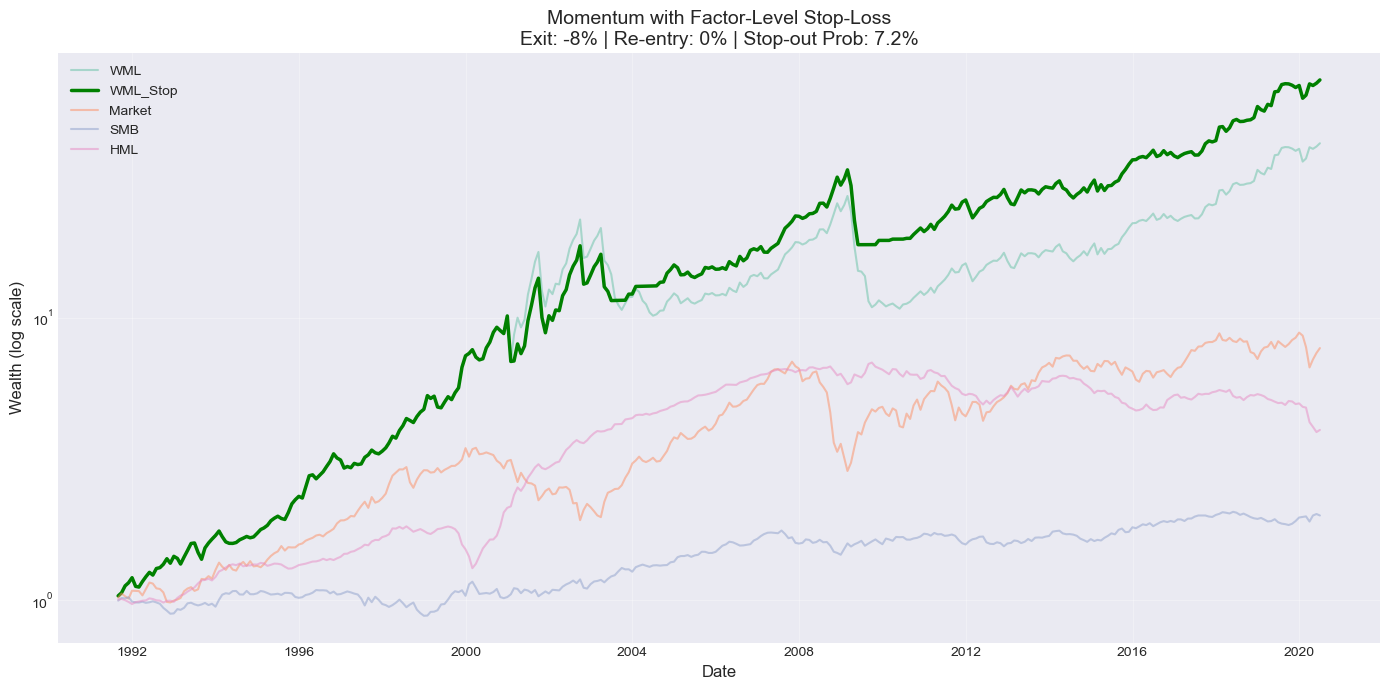

In [42]:
# =========================
# Plot Wealth
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Prepare data for plotting
plotdata = pd.concat([
    portfolios[["date"]].assign(Strategy="WML", wealth=portfolios["wealth_WML"].values),
    portfolios[["date"]].assign(Strategy="WML_Stop", wealth=portfolios["wealth_Stop"].values),
    portfolios[["date"]].assign(Strategy="Market", wealth=portfolios["wealth_Mkt"].values),
    portfolios[["date"]].assign(Strategy="SMB", wealth=portfolios["wealth_SMB"].values),
    portfolios[["date"]].assign(Strategy="HML", wealth=portfolios["wealth_HML"].values)
], ignore_index=True)

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

for strategy in plotdata["Strategy"].unique():
    data = plotdata[plotdata["Strategy"] == strategy]
    if strategy == "WML_Stop":
        ax.plot(data["date"], data["wealth"], linewidth=2.5, label=strategy, color="green")
    else:
        ax.plot(data["date"], data["wealth"], linewidth=1.5, alpha=0.5, label=strategy)

ax.set_yscale('log')
ax.set_title(f"Momentum with Factor-Level Stop-Loss\n"
             f"Exit: -{stop_loss_threshold*100:.0f}% | Re-entry: {reentry_threshold*100:.0f}% | "
             f"Stop-out Prob: {p_stop*100:.1f}%", fontsize=14)
ax.set_ylabel("Wealth (log scale)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

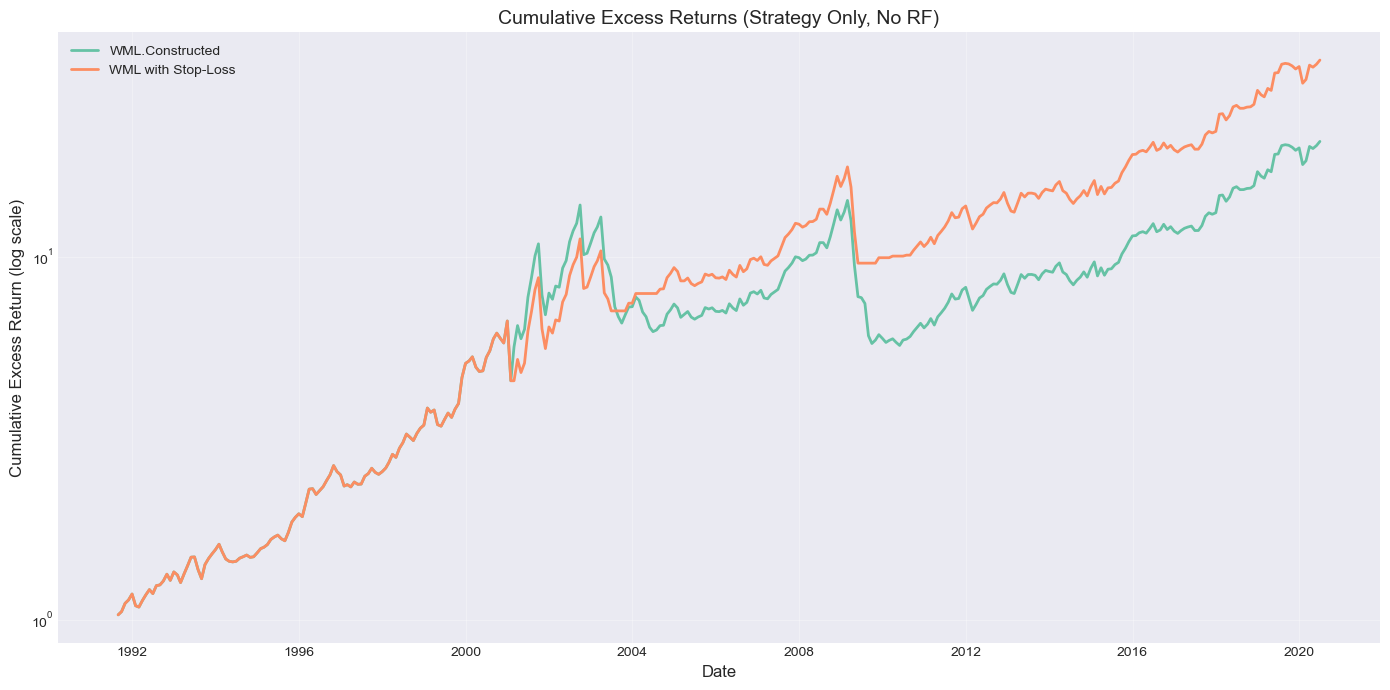

In [43]:
# =========================
# Plot Cumulative Excess Returns
# =========================

plotdata_excess = pd.concat([
    portfolios[["date"]].assign(Strategy="WML.Constructed", cumexcess=portfolios["cumexcess_WML"].values),
    portfolios[["date"]].assign(Strategy="WML with Stop-Loss", cumexcess=portfolios["cumexcess_Stop"].values)
], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 7))

for strategy in plotdata_excess["Strategy"].unique():
    data = plotdata_excess[plotdata_excess["Strategy"] == strategy]
    ax.plot(data["date"], data["cumexcess"], linewidth=2, label=strategy)

ax.set_yscale('log')
ax.set_title("Cumulative Excess Returns (Strategy Only, No RF)", fontsize=14)
ax.set_ylabel("Cumulative Excess Return (log scale)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Performance: 

In [44]:
# =========================
# Regression Helper Function
# =========================

import statsmodels.api as sm

def run_regression(y, X, add_const=True):
    """
    Run OLS regression and return results
    
    Parameters:
    y: dependent variable
    X: independent variables (DataFrame)
    add_const: whether to add constant term
    
    Returns:
    fitted model
    """
    if add_const:
        X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop').fit()
    return model

In [45]:
# =========================
# Sharpe Ratios
# =========================

print("\n" + "="*60)
print("PERFORMANCE METRICS (Annualized)")
print("="*60)

# a) Sharpe Ratio
sharpe_wml = portfolios["WML.Constructed"].mean() / portfolios["WML.Constructed"].std() * np.sqrt(12)

# For stop-loss, use only non-zero returns for std dev (when invested)
stop_nonzero = portfolios.loc[portfolios["WML_excess_active"] != 0, "WML_excess_active"]
if len(stop_nonzero) > 0:
    sharpe_stop = portfolios["WML_excess_active"].mean() / stop_nonzero.std() * np.sqrt(12)
else:
    sharpe_stop = np.nan

print("\nSHARPE RATIOS:")
print(f"  WML.Constructed:        {sharpe_wml:.3f}")
print(f"  WML with Stop-Loss:     {sharpe_stop:.3f}")


PERFORMANCE METRICS (Annualized)

SHARPE RATIOS:
  WML.Constructed:        0.607
  WML with Stop-Loss:     0.699


In [46]:
# =========================
# CAPM Alpha
# =========================

# b) CAPM Alpha
X_capm = portfolios[["MktRF"]]
y_wml = portfolios["WML.Constructed"]
y_stop = portfolios["WML_excess_active"]

capm_wml = run_regression(y_wml, X_capm)
capm_stop = run_regression(y_stop, X_capm)

print("\nCAPM ALPHA (Annualized):")
print(f"  WML.Constructed:        {capm_wml.params[0] * 12 * 100:.2f}% (t-stat: {capm_wml.tvalues[0]:.2f})")
print(f"  WML with Stop-Loss:     {capm_stop.params[0] * 12 * 100:.2f}% (t-stat: {capm_stop.tvalues[0]:.2f})")


CAPM ALPHA (Annualized):
  WML.Constructed:        15.19% (t-stat: 3.99)
  WML with Stop-Loss:     16.46% (t-stat: 4.59)


C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\3803060196.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {capm_wml.params[0] * 12 * 100:.2f}% (t-stat: {capm_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\3803060196.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {capm_wml.params[0] * 12 * 100:.2f}% (t-stat: {capm_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\3803060196.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

In [47]:
# =========================
# FF3 Alpha
# =========================

# c) Fama-French 3-Factor Alpha
X_ff3 = portfolios[["MktRF", "SMB", "HML"]]

ff3_wml = run_regression(y_wml, X_ff3)
ff3_stop = run_regression(y_stop, X_ff3)

print("\nFF3 ALPHA (Annualized):")
print(f"  WML.Constructed:        {ff3_wml.params[0] * 12 * 100:.2f}% (t-stat: {ff3_wml.tvalues[0]:.2f})")
print(f"  WML with Stop-Loss:     {ff3_stop.params[0] * 12 * 100:.2f}% (t-stat: {ff3_stop.tvalues[0]:.2f})")


FF3 ALPHA (Annualized):
  WML.Constructed:        15.24% (t-stat: 3.99)
  WML with Stop-Loss:     16.58% (t-stat: 4.61)


C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\930363680.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {ff3_wml.params[0] * 12 * 100:.2f}% (t-stat: {ff3_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\930363680.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {ff3_wml.params[0] * 12 * 100:.2f}% (t-stat: {ff3_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\930363680.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer key

In [48]:
# =========================
# Carhart 4-Factor Alpha
# =========================

# d) Carhart 4-Factor Alpha
X_carhart = portfolios[["MktRF", "SMB", "HML", "WML"]]

carhart_wml = run_regression(y_wml, X_carhart)
carhart_stop = run_regression(y_stop, X_carhart)

print("\nCARHART 4-FACTOR ALPHA (Annualized):")
print(f"  WML.Constructed:        {carhart_wml.params[0] * 12 * 100:.2f}% (t-stat: {carhart_wml.tvalues[0]:.2f})")
print(f"  WML with Stop-Loss:     {carhart_stop.params[0] * 12 * 100:.2f}% (t-stat: {carhart_stop.tvalues[0]:.2f})")


CARHART 4-FACTOR ALPHA (Annualized):
  WML.Constructed:        0.28% (t-stat: 0.09)
  WML with Stop-Loss:     3.20% (t-stat: 1.08)


C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\2823703190.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {carhart_wml.params[0] * 12 * 100:.2f}% (t-stat: {carhart_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\2823703190.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WML.Constructed:        {carhart_wml.params[0] * 12 * 100:.2f}% (t-stat: {carhart_wml.tvalues[0]:.2f})")
C:\Users\yinsiyuan\AppData\Local\Temp\ipykernel_4100\2823703190.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future v

In [49]:
# =========================
# Summary Statistics
# =========================

print("\n" + "="*60)
print("STOP-LOSS SUMMARY")
print("="*60)

# Stopping premium
stopping_premium = (portfolios["WML_excess_active"].mean() - portfolios["WML.Constructed"].mean()) * 12 * 100

print(f"Stop-Out Probability:                    {p_stop*100:.2f}%")
print(f"Months Stopped Out:                      {portfolios['state'].sum()} out of {len(portfolios)}")
print(f"Stopping Premium (annualized):           {stopping_premium:.2f}%")

print("\nMean Excess Returns (monthly):")
print(f"  WML.Constructed:                        {portfolios['WML.Constructed'].mean()*100:.2f}%")
print(f"  WML with Stop-Loss:                     {portfolios['WML_excess_active'].mean()*100:.2f}%")

print("\nMean Total Returns (monthly, including RF):")
print(f"  WML.Constructed:                        {portfolios['total_WML'].mean()*100:.2f}%")
print(f"  WML with Stop-Loss:                     {portfolios['total_WML_stop'].mean()*100:.2f}%")

print("\nFinal Wealth ($1 invested):")
print(f"  WML.Constructed:                        ${portfolios['wealth_WML'].iloc[-1]:.2f}")
print(f"  WML with Stop-Loss:                     ${portfolios['wealth_Stop'].iloc[-1]:.2f}")
print(f"  Market:                                 ${portfolios['wealth_Mkt'].iloc[-1]:.2f}")
print(f"  SMB:                                    ${portfolios['wealth_SMB'].iloc[-1]:.2f}")
print(f"  HML:                                    ${portfolios['wealth_HML'].iloc[-1]:.2f}")
print("="*60)


STOP-LOSS SUMMARY
Stop-Out Probability:                    7.20%
Months Stopped Out:                      322 out of 347
Stopping Premium (annualized):           1.52%

Mean Excess Returns (monthly):
  WML.Constructed:                        1.08%
  WML with Stop-Loss:                     1.20%

Mean Total Returns (monthly, including RF):
  WML.Constructed:                        1.28%
  WML with Stop-Loss:                     1.41%

Final Wealth ($1 invested):
  WML.Constructed:                        $41.40
  WML with Stop-Loss:                     $69.39
  Market:                                 $7.80
  SMB:                                    $1.99
  HML:                                    $4.00
